In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score, davies_bouldin_score

In [22]:
import os
file=r"C:\Users\User\Desktop\workshop\New folder\New folder\Disease Outbreak\climate_disease_dataset.csv"
print(os.path.exists(file))

True


In [23]:

df=pd.read_csv(file)
df.head()

,year,month,country,region,avg_temp_c,precipitation_mm,air_quality_index,uv_index,malaria_cases,dengue_cases,population_density,healthcare_budget
0,2000,1,Palestinian Territory,Central,28.132468,152.083870,110.487231,12.000000,53,145,113,1068
1,2000,2,Palestinian Territory,Central,30.886500,119.591418,83.467928,12.000000,132,48,113,1068
2,2000,3,Palestinian Territory,Central,31.366433,95.876124,93.095292,12.000000,34,80,113,1068
3,2000,4,Palestinian Territory,Central,28.481870,175.315731,105.530192,9.395894,23,133,113,1068
4,2000,5,Palestinian Territory,Central,26.890370,191.445990,60.205979,9.935726,39,74,113,1068


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34560 entries, 0 to 34559
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                34560 non-null  int64  
 1   month               34560 non-null  int64  
 2   country             34560 non-null  object 
 3   region              34560 non-null  object 
 4   avg_temp_c          34560 non-null  float64
 5   precipitation_mm    34560 non-null  float64
 6   air_quality_index   34560 non-null  float64
 7   uv_index            34560 non-null  float64
 8   malaria_cases       34560 non-null  int64  
 9   dengue_cases        34560 non-null  int64  
 10  population_density  34560 non-null  int64  
 11  healthcare_budget   34560 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 3.2+ MB


In [25]:
df.describe()

,year,month,avg_temp_c,precipitation_mm,air_quality_index,uv_index,malaria_cases,dengue_cases,population_density,healthcare_budget
count,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000
mean,2011.500000,6.500000,20.395234,192.667977,43.787766,10.210855,70.519560,75.941464,266.900000,2764.650000
std,6.922287,3.452102,8.410940,90.503990,33.079697,1.936540,46.130774,37.323807,136.001073,1418.119148
min,2000.000000,1.000000,-2.557056,0.000000,0.000000,0.870704,0.000000,0.000000,50.000000,205.000000
25%,2005.750000,3.750000,14.404089,124.641424,15.322767,8.921094,32.000000,48.000000,136.250000,1435.500000
50%,2011.500000,6.500000,20.351749,195.315309,40.685931,10.760990,69.000000,76.000000,277.500000,2859.000000
75%,2017.250000,9.250000,26.342978,260.147603,68.402041,12.000000,107.000000,104.000000,384.750000,3996.750000
max,2023.000000,12.000000,44.583564,485.704079,168.847690,12.000000,201.000000,181.000000,498.000000,4969.000000


In [26]:
df.isnull().sum()

year                  0
month                 0
country               0
region                0
avg_temp_c            0
precipitation_mm      0
air_quality_index     0
uv_index              0
malaria_cases         0
dengue_cases          0
population_density    0
healthcare_budget     0
dtype: int64

In [27]:
 #Total outbreak burden
df["total_cases"] = df["malaria_cases"] + df["dengue_cases"]

# Cyclical month encoding
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

In [28]:
cluster_features = df[[
    'avg_temp_c',
    'precipitation_mm',
    'air_quality_index',
    'uv_index',
    'population_density',
    'healthcare_budget',
    'total_cases',
    'month_sin',
    'month_cos'
]]

Feature	Why it's useful	What it tells the model
avg_temp_c	Temperature affects the survival and spread of pathogens, insects, and vectors.	Whether the climate is favorable for disease transmission.
precipitation_mm	Rainfall influences water quality, flooding, mosquito breeding, and sanitation conditions.	Whether wet conditions may increase outbreak risk.
air_quality_index	Poor air quality can worsen respiratory illnesses and weaken population health.	The environmental health burden on a population.
uv_index	UV radiation can reduce the survival of some microorganisms outdoors.	Whether environmental conditions may naturally suppress or favor pathogens.
population_density	Diseases spread more easily where people live close together.	Potential transmission opportunity among people.
healthcare_budget	Represents healthcare capacity and preparedness.	Ability of a region to detect, manage, and contain outbreaks.
total_cases	Direct indicator of disease burden.	Current severity of disease activity.
month_sin	Captures seasonality in a continuous way.	Seasonal disease patterns without abrupt month changes.
month_cos	Works together with month_sin to encode cyclical time.

In [29]:
Scaler=StandardScaler()
X_scaled=Scaler.fit_transform(cluster_features)

In [30]:
print(X_scaled[:5])

[[ 9.19914533e-01 -4.48429882e-01  2.01635557e+00  9.23900367e-01
  -1.13162509e+00 -1.19642595e+00  7.92276131e-01  7.07106781e-01
   1.22474487e+00]
 [ 1.24735374e+00 -8.07451868e-01  1.19954957e+00  9.23900367e-01
  -1.13162509e+00 -1.19642595e+00  5.15573497e-01  1.22474487e+00
   7.07106781e-01]
 [ 1.30441522e+00 -1.06949155e+00  1.49058923e+00  9.23900367e-01
  -1.13162509e+00 -1.19642595e+00 -4.99002830e-01  1.41421356e+00
   1.52888398e-16]
 [ 9.61456493e-01 -1.91731843e-01  1.86650199e+00 -4.20839509e-01
  -1.13162509e+00 -1.19642595e+00  1.46636650e-01  1.22474487e+00
  -7.07106781e-01]
 [ 7.72235952e-01 -1.35022155e-02  4.96330147e-01 -1.42074526e-01
  -1.13162509e+00 -1.19642595e+00 -5.14375199e-01  7.07106781e-01
  -1.22474487e+00]]


PCA(Dimension Redundancy)

In [11]:
X_decomposed = PCA(n_components=2,random_state=42)
X_pca=X_decomposed.fit_transform(X_scaled)

In [12]:
print(X_pca[:15])

[[ 2.0762565  -0.77530089]
 [ 1.73022193  0.03380265]
 [ 1.9763666  -0.1316449 ]
 [ 1.99966862 -0.63996381]
 [ 0.89701169  0.19509487]
 [ 1.2269285  -1.05964072]
 [ 0.95912244 -1.56444306]
 [ 0.62941552 -1.86462663]
 [ 0.73091604 -1.31451631]
 [ 0.91031521 -1.66059486]
 [ 1.54359754 -1.96104126]
 [ 1.09355424 -1.01659069]
 [ 1.58825674 -0.28558676]
 [ 2.53697009 -0.41129816]
 [ 2.2334541  -0.33970262]]


In [13]:
print(X_pca[:15])

[[ 2.0762565  -0.77530089]
 [ 1.73022193  0.03380265]
 [ 1.9763666  -0.1316449 ]
 [ 1.99966862 -0.63996381]
 [ 0.89701169  0.19509487]
 [ 1.2269285  -1.05964072]
 [ 0.95912244 -1.56444306]
 [ 0.62941552 -1.86462663]
 [ 0.73091604 -1.31451631]
 [ 0.91031521 -1.66059486]
 [ 1.54359754 -1.96104126]
 [ 1.09355424 -1.01659069]
 [ 1.58825674 -0.28558676]
 [ 2.53697009 -0.41129816]
 [ 2.2334541  -0.33970262]]


In [14]:
for i in range(2, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    silhouette_avg = silhouette_score(X_pca, labels)
    db_score = davies_bouldin_score(X_pca, labels)
    print(f"K={i}: Silhouette={silhouette_avg:.3f}, DB Score={db_score:.3f}")

K=2: Silhouette=0.346, DB Score=1.176
K=3: Silhouette=0.363, DB Score=0.880
K=4: Silhouette=0.347, DB Score=0.894
K=5: Silhouette=0.325, DB Score=0.951
K=6: Silhouette=0.351, DB Score=0.812
K=7: Silhouette=0.349, DB Score=0.804
K=8: Silhouette=0.326, DB Score=0.890
K=9: Silhouette=0.326, DB Score=0.867


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

for eps in [0.3, 0.5]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_pca)
    

    silhouette_avg = silhouette_score(X_pca, labels)
    db_score = davies_bouldin_score(X_pca, labels)
    print(f"DBSCAN eps={eps}: Silhouette={silhouette_avg:.3f}, DB Score={db_score:.3f}")
    

[-1  0]
DBSCAN eps=0.3: Silhouette=0.492, DB Score=0.747
[-1  0]
DBSCAN eps=0.5: Silhouette=0.532, DB Score=0.322


In [20]:
#Gaussian Mixture Model
for i in range(2, 10):
     gmm = GaussianMixture(n_components=i, covariance_type='full', random_state=42)
     gmm.fit(X_pca)
     labels = gmm.predict(X_pca)
     silhouette_avg = silhouette_score(X_pca, labels)
     db_score = davies_bouldin_score(X_pca, labels)
     print(f"GMM K={i}: Silhouette={silhouette_avg:.3f}, DB Score={db_score:.3f}")


GMM K=2: Silhouette=0.341, DB Score=1.191
GMM K=3: Silhouette=0.349, DB Score=0.890
GMM K=4: Silhouette=0.343, DB Score=0.907
GMM K=5: Silhouette=0.219, DB Score=1.939
GMM K=6: Silhouette=0.240, DB Score=1.546
GMM K=7: Silhouette=0.231, DB Score=1.075
GMM K=8: Silhouette=0.200, DB Score=1.693
GMM K=9: Silhouette=0.218, DB Score=1.251


In [ ]:
score = silhouette_score(X_pca, labels)
db_score = davies_bouldin_score(X_pca, labels)
print("Silhouette Score (GMM):", score)
print("Davies-Bouldin Score (GMM):", db_score)

Silhouette Score (GMM): 0.32167082755751875
Davies-Bouldin Score (GMM): 0.8923199080100078


In [31]:
k_range = range(2, 11)

wcss = []
silhouette_scores_kmeans = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    wcss.append(kmeans.inertia_)
    silhouette_scores_kmeans.append(silhouette_score(X_scaled, labels))

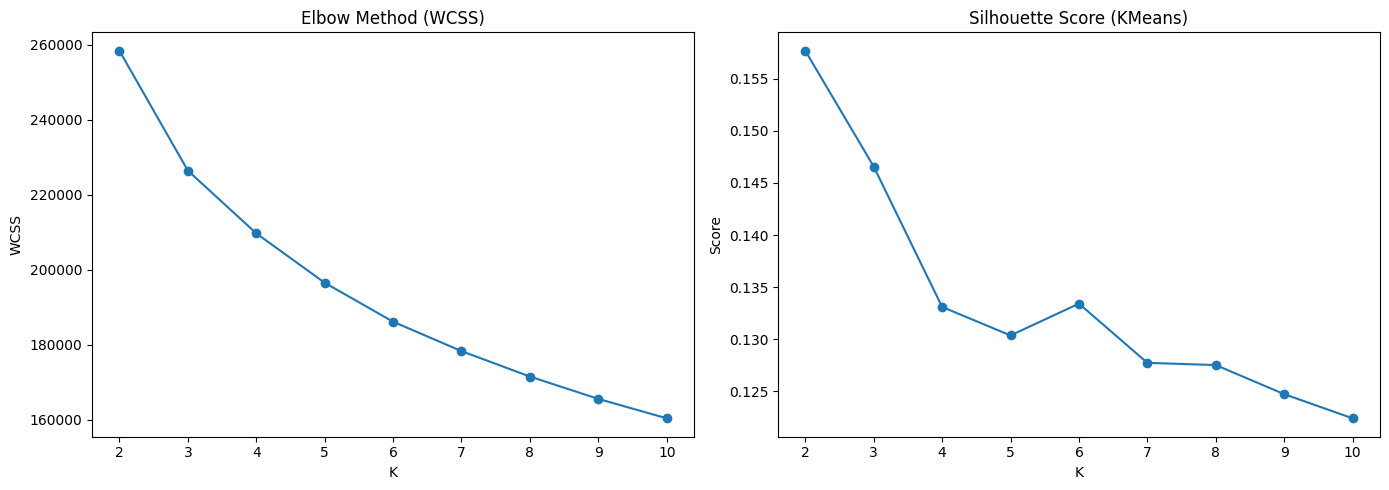

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, wcss, marker='o')
axes[0].set_title("Elbow Method (WCSS)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("WCSS")

axes[1].plot(k_range, silhouette_scores_kmeans, marker='o')
axes[1].set_title("Silhouette Score (KMeans)")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

In [33]:
best_k_kmeans = k_range[np.argmax(silhouette_scores_kmeans)]
print("Best KMeans K:", best_k_kmeans)

Best KMeans K: 2


In [34]:
kmeans = KMeans(n_clusters=best_k_kmeans, random_state=42, n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

In [35]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

df["dbscan_cluster"] = db_labels

# Check cluster distribution
print("DBSCAN clusters:", np.unique(db_labels, return_counts=True))

DBSCAN clusters: (array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
       33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49,
       50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61]), array([34206,     5,    10,     5,     6,     5,     5,     5,     5,
           5,     5,     5,     5,     5,     9,     5,     5,     6,
           6,     7,     5,     5,     6,     5,     6,     5,     8,
           7,     5,     5,     5,     6,     7,     5,     6,     4,
           7,     5,     5,     5,     5,     5,     5,     6,     5,
           5,     5,     5,     6,     5,     5,    12,     8,     7,
           6,     5,     6,     5,     6,     5,     5,     6,     5]))


In [36]:
if len(set(db_labels)) > 1 and len(set(db_labels)) > 2:
    sil_dbscan = silhouette_score(X_scaled, db_labels)
    db_dbscan = davies_bouldin_score(X_scaled, db_labels)

    print("DBSCAN Silhouette:", sil_dbscan)
    print("DBSCAN DB Index:", db_dbscan)
else:
    print("DBSCAN: Not enough clusters for reliable evaluation")

DBSCAN Silhouette: -0.48095331583939993
DBSCAN DB Index: 1.1796405491147766


In [39]:
gmm_range = range(2, 11)

silhouette_scores_gmm = []

for k in gmm_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(X_scaled)

    labels = gmm.predict(X_scaled)

    silhouette_scores_gmm.append(silhouette_score(X_scaled, labels))

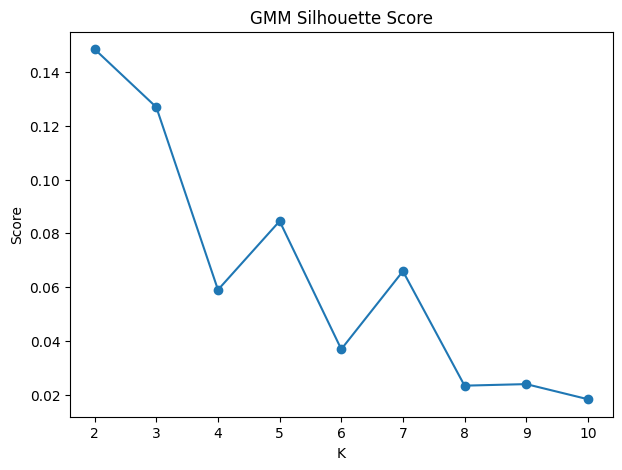

In [40]:
plt.figure(figsize=(7,5))
plt.plot(gmm_range, silhouette_scores_gmm, marker='o')
plt.title("GMM Silhouette Score")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()

In [41]:
best_k_gmm = gmm_range[np.argmax(silhouette_scores_gmm)]
print("Best GMM K:", best_k_gmm)

Best GMM K: 2


In [42]:
gmm = GaussianMixture(n_components=best_k_gmm, random_state=42)
df["gmm_cluster"] = gmm.fit_predict(X_scaled)

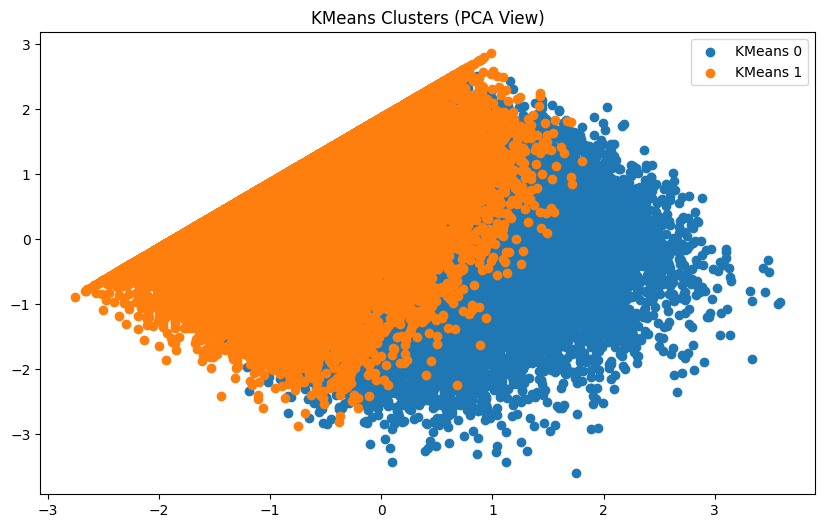

In [43]:
plt.figure(figsize=(10,6))

for i in range(best_k_kmeans):
    plt.scatter(
        X_pca[df["kmeans_cluster"] == i, 0],
        X_pca[df["kmeans_cluster"] == i, 1],
        label=f"KMeans {i}"
    )

plt.title("KMeans Clusters (PCA View)")
plt.legend()
plt.show()

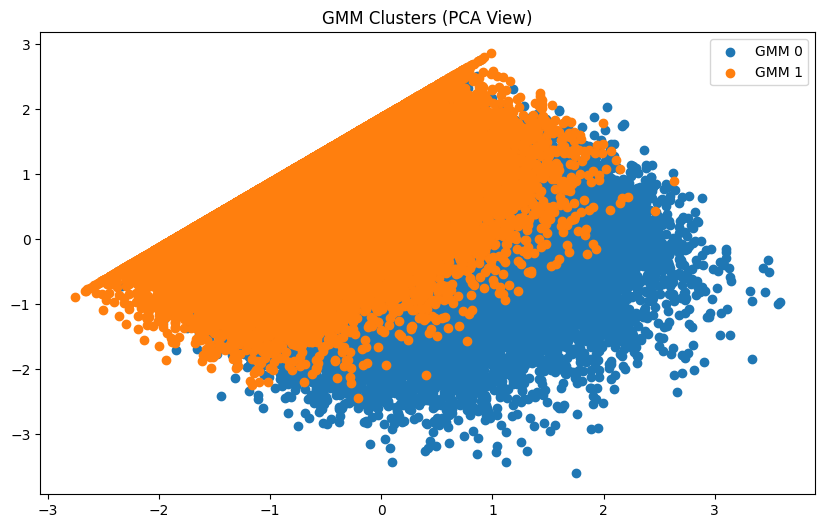

In [44]:
plt.figure(figsize=(10,6))

for i in range(best_k_gmm):
    plt.scatter(
        X_pca[df["gmm_cluster"] == i, 0],
        X_pca[df["gmm_cluster"] == i, 1],
        label=f"GMM {i}"
    )

plt.title("GMM Clusters (PCA View)")
plt.legend()
plt.show()

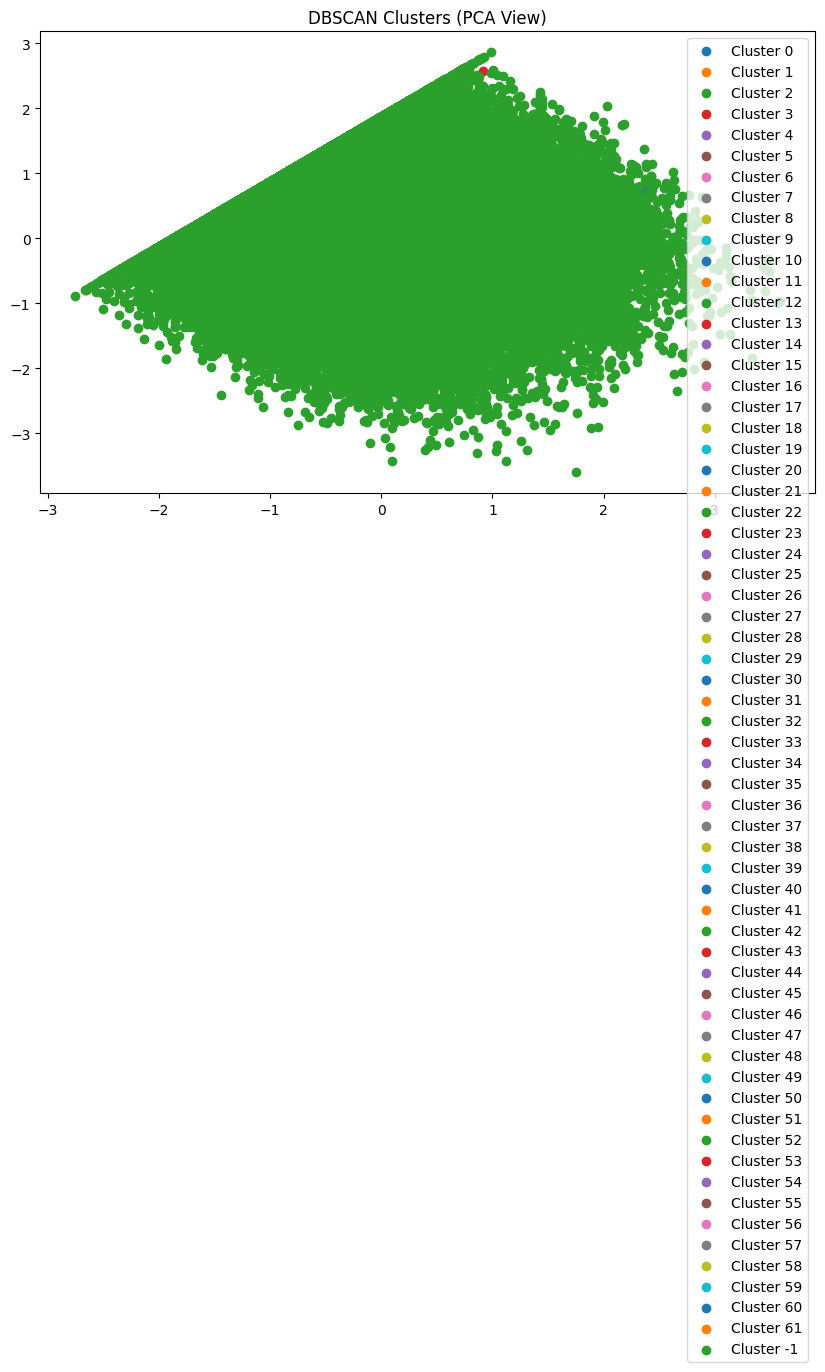

In [37]:
plt.figure(figsize=(10,6))

unique_labels = set(db_labels)

for i in unique_labels:
    plt.scatter(
        X_pca[df["dbscan_cluster"] == i, 0],
        X_pca[df["dbscan_cluster"] == i, 1],
        label=f"Cluster {i}"
    )

plt.title("DBSCAN Clusters (PCA View)")
plt.legend()
plt.show()

In [60]:
cluster_risk = df.groupby("gmm_cluster")["total_cases"].mean().sort_values()

In [61]:
risk_map = {
    cluster_risk.index[0]: "Low Risk",
    cluster_risk.index[1]: "High Risk"
}

df["risk_level"] = df["gmm_cluster"].map(risk_map)

In [63]:
print(df[["gmm_cluster", "risk_level"]].head(197))

     gmm_cluster risk_level
0              0  High Risk
1              0  High Risk
2              0  High Risk
3              0  High Risk
4              0  High Risk
..           ...        ...
192            0  High Risk
193            0  High Risk
194            0  High Risk
195            0  High Risk
196            0  High Risk

[197 rows x 2 columns]


In [57]:
cluster_profile = df.groupby('gmm_cluster').mean(numeric_only=True)

print(cluster_profile)

                    year     month  avg_temp_c  precipitation_mm  \
gmm_cluster                                                        
0            2011.270659  6.480340   21.148590        205.205279   
1            2011.686811  6.516014   19.781585        182.455664   

             air_quality_index   uv_index  malaria_cases  dengue_cases  \
gmm_cluster                                                              
0                    70.631905  10.411464      80.064845     83.132203   
1                    21.921759  10.047449      62.744408     70.084217   

             population_density  healthcare_budget  total_cases  month_sin  \
gmm_cluster                                                                  
0                    234.944373        1398.890357   163.197048   0.003745   
1                    292.929592        3877.135304   132.828625  -0.003051   

             month_cos  kmeans_cluster  dbscan_cluster  
gmm_cluster                                             
0  

In [58]:
df["risk_level"]=cluster_profile["total_cases"].rank().map({1: "Low Risk", 2: "High Risk"})
df["risk_level"].head(17)

0     High Risk
1      Low Risk
2           NaN
3           NaN
4           NaN
5           NaN
6           NaN
7           NaN
8           NaN
9           NaN
10          NaN
11          NaN
12          NaN
13          NaN
14          NaN
15          NaN
16          NaN
Name: risk_level, dtype: object

The Gaussian Mixture Model identified two distinct outbreak-risk profiles. Cluster 0 was characterized by higher rainfall, poorer air quality, lower healthcare budgets, and substantially higher malaria and dengue case counts. This cluster represents high-risk outbreak regions. Cluster 1 exhibited lower disease incidence despite having higher population density, which coincided with significantly greater healthcare investment. These findings suggest that healthcare capacity may play a critical role in mitigating disease outbreaks even in densely populated environments.


In [52]:
df["gmm_cluster"].value_counts()

gmm_cluster
1    19046
0    15514
Name: count, dtype: int64

In [28]:

import joblib

joblib.dump(X_decomposed, "climate_diseases_pca.pkl")
joblib.dump(Scaler, "climate_diseases_scaler.pkl")
joblib.dump(gmm, "climate_diseases_model.pkl")

['climate_diseases_model.pkl']